<a href="https://colab.research.google.com/github/LucioFassarella/AMQ/blob/main/Camila_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OCR

https://github.com/damiles/basicOCR



In [1]:
'''
Métodos auxiliares
'''

def binfloat(f, num_digitos = int):
    whole, dec = str(f).split(".")
    res = bin(int(whole))[2:] + "."

    dec = float("0." + dec)
    for _ in range(num_digitos):
        dec *= 2
        bit = int(dec)
        res += str(bit)
        dec -= bit
        if dec == 0: break

    #aproximação binária para resultado igual a 1
    if(res==1.0):
      res = 0.1111
    return res

In [2]:
import cv2
import numpy as np

def analyze_pixel_distribution(img_binary):
    """
    Analisa a distribuição de bits 1 (objeto) nas 4 metades da imagem.
    Assume que: Objeto = 1, Fundo = 0.
    Parâmetros:
      img_binary: imagem contendo 0 e 1.
    Retorna:
      features_images: dicionário contendo as features da imagem inteira.
      features_bbox: dicionário de bits contendo as features apenas dentro da
      delimitação da imagemm
    """
    # Garante que a imagem está em 1 único canal (escala de cinza/binária)
    if len(img_binary.shape) == 3:
        img_binary = cv2.cvtColor(img_binary, cv2.COLOR_BGR2GRAY)

    # Converte para uint8 para compatibilidade com cv2.threshold
    img_binary = img_binary.astype(np.uint8)

    # Garante que a imagem está estritamente binária com valores 0 e 1
    # (Se vier do OpenCV padrão onde branco é 255, isso converte para 1)
    _, img_bin = cv2.threshold(img_binary, 0, 1, cv2.THRESH_BINARY)

    height, width = img_bin.shape[:2]

    # -------------------------------------------------------------
    # ABORDAGEM 1: Contagem considerando a imagem INTEIRA
    # -------------------------------------------------------------
    mid_y = height // 2
    mid_x = width // 2

    # Recorta as fatias da imagem e soma os bits 1
    total_superior = np.sum(img_bin[0:mid_y, :])
    total_inferior = np.sum(img_bin[mid_y:height, :])
    total_esquerda = np.sum(img_bin[:, 0:mid_x])
    total_direita  = np.sum(img_bin[:, mid_x:width])

    # -------------------------------------------------------------
    # ABORDAGEM 2: Contagem focada apenas na Bounding Box do número
    # (Evita que o posicionamento do número na tela altere o resultado)
    # -------------------------------------------------------------
    # Encontra onde estão os bits 1 (o número desenhado)
    pts = np.argwhere(img_bin == 1)

    if len(pts) == 0:
        # Imagem vazia (sem nenhum bit 1)
        bb_superior = bb_inferior = bb_esquerda = bb_direita = 0
    else:
        # Coordenadas da Bounding Box: [ymin, xmin] até [ymax, xmax]
        ymin, xmin = pts.min(axis=0)
        ymax, xmax = pts.max(axis=0)

        # Recorta apenas a região ocupada pelo número
        roi = img_bin[ymin:ymax+1, xmin:xmax+1]
        roi_h, roi_w = roi.shape

        # Define os meios da Bounding Box
        roi_mid_y = roi_h // 2
        roi_mid_x = roi_w // 2

        # Conta os bits 1 dentro das metades da Bounding Box
        bb_superior = np.sum(roi[0:roi_mid_y, :])
        bb_inferior = np.sum(roi[roi_mid_y:roi_h, :])
        bb_esquerda = np.sum(roi[:, 0:roi_mid_x])
        bb_direita  = np.sum(roi[:, roi_mid_x:roi_w])
    '''
    # Exibe os resultados
    print("=" * 50)
    print("      CONTAGEM DE BITS 1 (MÉTRICAS DA IMAGEM)")
    print("=" * 50)
    print(f"Dimensões da imagem: {width}x{height}")
    print("-" * 50)
    print("CONSIDERANDO A IMAGEM INTEIRA:")
    print(f"  • Metade Superior: {total_superior} bits")
    print(f"  • Metade Inferior: {total_inferior} bits")
    print(f"  • Metade Esquerda: {total_esquerda} bits")
    print(f"  • Metade Direita:  {total_direita} bits")
    print("-" * 50)
    print("CONSIDERANDO APENAS A BOUNDING BOX DO NÚMERO:")
    print(f"  • Metade Superior: {bb_superior} bits")
    print(f"  • Metade Inferior: {bb_inferior} bits")
    print(f"  • Metade Esquerda: {bb_esquerda} bits")
    print(f"  • Metade Direita:  {bb_direita} bits")
    print("=" * 50)
    '''
    # Retorna os dicionários
    features_imagem = {"sup": total_superior, "inf": total_inferior,
                       "esq": total_esquerda, "dir": total_direita}
    features_bbox = {"sup": bb_superior, "inf": bb_inferior, "esq": bb_esquerda,
                     "dir": bb_direita}

    if(features_imagem["inf"]==0):
      Hr = features_imagem["sup"]/1.0
    else:
      Hr = features_imagem["sup"]/features_imagem["inf"]

    if(features_imagem["dir"]==0):
      Vr= features_imagem["esq"]/1.0
    else:
      Vr = features_imagem["esq"]/features_imagem["dir"]

    return Hr, Vr

In [23]:
import numpy as np

def importar_pbm_p1(caminho_arquivo):
    """
    Lê um arquivo PBM (formato P1 ASCII), ignorando comentários,
    e retorna uma matriz binária (NumPy array).
    """
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        linhas = f.readlines()

    dados_uteis = []
    largura = 0
    altura = 0
    dimensoes_encontradas = False

    for linha in linhas:
        linha = linha.strip()

        # Ignora linhas vazias ou comentários
        if not linha or linha.startswith('#'):
            continue

        # Pula o cabeçalho 'P1' se ele existir no arquivo
        if linha == 'P1':
            continue

        # A primeira linha que não é comentário/P1 deve ser a dimensão (ex: "128 128")
        if not dimensoes_encontradas:
            partes = linha.split()
            largura = int(partes[0])
            altura = int(partes[1])
            dimensoes_encontradas = True
            continue

        # O que sobrar são os bits da imagem
        dados_uteis.append(linha)

    # Junta todas as linhas de bits em uma única string e remove espaços se houver
    string_bits = "".join(dados_uteis).replace(" ", "").replace("\n", "")

    # Converte a string de caracteres '0' e '1' em uma lista de inteiros
    lista_pixels = [int(bit) for bit in string_bits]

    # Transforma em uma matriz bidimensional (Numpy Array) com as dimensões corretas
    matriz_imagem = np.array(lista_pixels).reshape((altura, largura))

    return matriz_imagem

In [66]:
#Passo 1.1:Importando Dados Teste
def importar_pacote_imagens_pbm(caminho_pasta, numero_inicial, quantidade):
    """
    Importa uma sequência de arquivos .pbm numerados sequencialmente a partir de um diretório.

    Parâmetros:
    - caminho_pasta (str): Caminho do diretório onde as imagens estão (ex: "/content/.../8/")
    - numero_inicial (int): O número do primeiro arquivo a ser importado (ex: 850)
    - quantidade (int): Quantidade de imagens a serem importadas em sequência (padrão: 6)

    Retorna:
    - list: Lista contendo as matrizes das imagens importadas com sucesso.
    """

    import os

    if quantidade is None:
        quantidade = len(os.listdir('caminho_pasta'))

    lista_de_matrizes = []
    numero_atual = numero_inicial

    # Garante que o caminho da pasta termine com uma barra para não quebrar a string
    if not caminho_pasta.endswith('/'):
        caminho_pasta += '/'

    for i in range(quantidade):
        # Monta o caminho completo usando os parâmetros dinâmicos
        caminho_completo = f"{caminho_pasta}{numero_atual}.pbm"

        try:
            # Importa a matriz atual usando função importar_pbm_p1
            matriz_atual = importar_pbm_p1(caminho_completo)

            # Adiciona a matriz na lista de armazenamento
            lista_de_matrizes.append(matriz_atual)
            print(f"[{i+1}/{quantidade}] {caminho_completo} importado com sucesso!")

        except FileNotFoundError:
            print(f"Erro: O arquivo {caminho_completo} não foi encontrado. Interrompendo importação.")
            break  # Para o loop se um arquivo falhar

        # Incrementa para o próximo número de arquivo
        numero_atual += 1

    # --- Resumo pós-loop ---
    print("\n--- Resumo da Importação ---")
    if lista_de_matrizes:
        print(f"Total de {len(lista_de_matrizes)} imagens importadas com sucesso!")
        # Verifica se o objeto retornado possui o atributo shape (como matrizes NumPy)
        if hasattr(lista_de_matrizes[0], 'shape'):
            print(f"Formato de cada matriz: {lista_de_matrizes[0].shape}")
    else:
        print("Nenhuma imagem foi importada.")

    return lista_de_matrizes

In [26]:
#PASSO 2: Extraindo Hr, Vr
def extrair_caracteristicas_imagens(lista_de_matrizes, exibir=True):
    """
    Obtém as razões horizontais (Hr) e verticais (Vr) de uma lista de imagens binárias.

    Parâmetros:
    - lista_de_matrizes (list): Lista contendo as matrizes das imagens.
    - exibir (bool): Se True, imprime a lista formatada na tela.

    Retorna:
    - list: Lista de listas no formato [[Hr, Vr], [Hr, Vr], ...] com valores float.
    """
    lista_hr_vr = []

    # Passo 3: Processa cada imagem para obter Hr e Vr
    for matriz in lista_de_matrizes:
        Hr, Vr = analyze_pixel_distribution(matriz)
        lista_hr_vr.append([float(Hr), float(Vr)]) # Garante que os valores sejam float

    # Imprime os resultados se verbose for True
    if exibir:
        for i, valores in enumerate(lista_hr_vr):
            print(f"Lista_hr_vr[{i}]: {valores}")

    return lista_hr_vr

In [28]:
#PASSO 4: NORMALIZAR DADOS OBTIDOS NO PASSO ANTERIOR
def normalizar_caracteristicas(lista_hr_vr, exibir=True):
    """
    Normaliza os valores de Hr e Vr dividindo-os pelo maior valor de cada coluna.
    Substitui o valor 1.0 por 0.1111 caso a normalização resulte em 1.

    Parâmetros:
    - lista_hr_vr (list): Lista de listas no formato [[Hr, Vr], ...]
    - exibir (bool): Se True, imprime a lista normalizada na tela.

    Retorna:
    - list: Nova lista com os valores devidamente normalizados.
    """
    # Encontra o maior valor de Hr (índice 0) e Vr (índice 1)
    maior_hr = max(lista_hr_vr, key=lambda x: x[0])[0]
    maior_vr = max(lista_hr_vr, key=lambda x: x[1])[1]

    lista_normalizada = []

    # Processa e normaliza cada par [Hr, Vr]
    for i, par in enumerate(lista_hr_vr):
        hr_norm = par[0] / maior_hr
        vr_norm = par[1] / maior_vr

        # Aplica a sua regra de corte para evitar o valor 1.0
        '''
        if hr_norm == 1.0:
            hr_norm = 0.1111

        if vr_norm == 1.0:
            vr_norm = 0.1111
        '''

        # Adiciona os valores transformados à nova lista
        lista_normalizada.append([hr_norm, vr_norm])

        if exibir:
            print(f"Lista_hr_vr[{i}]: [{hr_norm}, {vr_norm}]")

    return lista_normalizada

In [41]:
#PASSO 5: TRANSFORMAR DADOS PARA VALORES BINÁRIOS

def converter_recursos_para_binario(lista_hr_vr, num_digitos=7, exibir=True):
    """
    Converte os valores float (Hr e Vr) de uma lista para suas representações binárias
    utilizando a função binfloat().

    Parâmetros:
    - lista_hr_vr (list): Lista de listas no formato [[Hr, Vr], ...] com valores float.
    - num_digitos (int): Quantidade de dígitos/bits para a conversão (padrão: 8).
    - exibir (bool): Se True, imprime a lista convertida na tela.

    Retorna:
    - list: Nova lista contendo os valores convertidos em binário pela função binfloat.
    """
    lista_binaria = []

    # Passo 5: Aplica a função binfloat em cada valor de Hr e Vr
    for i, par in enumerate(lista_hr_vr):
        hr_bin = binfloat(par[0], num_digitos=num_digitos)
        vr_bin = binfloat(par[1], num_digitos=num_digitos)

        # Adiciona o par convertido à nova lista
        lista_binaria.append([hr_bin, vr_bin])

        if exibir:
            print(f"Lista_hr_vr4[{i}]: [{hr_bin}, {vr_bin}]")

    return lista_binaria

In [44]:
#Paso 6.1: ORGANIZANDO DADOS
def mesclar_recursos_binarios(lista_hr_vr_binaria, exibir=True):
    """
    Mescla (concatena) os componentes binários Hr e Vr de cada imagem em uma única string.

    Parâmetros:
    - lista_hr_vr_binaria (list): Lista de listas no formato [[hr_bin, vr_bin], ...]
    - verbose (bool): Se True, imprime a lista mesclada na tela.

    Retorna:
    - list: Nova lista contendo as strings binárias mescladas (ex: ['01011100', ...]).
    """
    lista_mesclada = []

    # Passo 6.1: Mesclar Hr e Vr em um elemento só
    for i, par in enumerate(lista_hr_vr_binaria):
        # Concatena a string do Hr com a string do Vr
        recurso_mesclado = par[0] + par[1]
        lista_mesclada.append(recurso_mesclado)

        if exibir:
            print(f"ListaHrVr4[{i}]: {recurso_mesclado}")

    return lista_mesclada

In [46]:
#PASSO 6.2: ORGANIZANDO DADOS:
def transformar_para_vetor_bits(lista_hr_vr_binaria, exibir=True):
    """
    Transforma os elementos em strings, remove apenas os pontos decimais
    e converte absolutamente todos os dígitos (incluindo os zeros) em um vetor de inteiros.
    """
    lista_vetores_finais = []

    for i, elemento in enumerate(lista_hr_vr_binaria):
        # 1. Se o elemento for uma lista/tupla (ex: ['0.111.100']), junta em uma string só
        if isinstance(elemento, (list, tuple)):
            texto_puro = "".join(str(x) for x in elemento)
        else:
            texto_puro = str(elemento)

        # 2. Remove APENAS o caractere de ponto decimal
        string_sem_pontos = texto_puro.replace(".", "")

        # 3. Transforma cada caractere numérico em um número inteiro, mantendo todos os zeros
        vetor_bits = [int(bit) for bit in string_sem_pontos if bit.isdigit()]

        # 4. Guarda o vetor na lista final
        lista_vetores_finais.append(vetor_bits)

        if exibir:
            print(f"ListaHrVr[{i}]: {vetor_bits}")

    return lista_vetores_finais

In [48]:
#PASSO 7: CLASSIFICANDO DADOS
def adicionar_exemplos_ao_dataset(lista_vetores, classe, lista_dados_existente=None, exibir=True):
    """
    Adiciona os vetores de bits e suas respectivas classificações (labels)
    a uma lista unificada de dados.

    Parâmetros:
    - lista_vetores (list): Lista de vetores de bits (saída do Passo 6.2).
    - classe (int): O rótulo da classe (ex: 0 para o caractere 4, 1 para o caractere 8).
    - lista_dados_existente (list): Uma lista existente para acumular os dados. Se None, cria uma nova.
    - exibir (bool): Se True, imprime a lista de dados na tela.

    Retorna:
    - list: Lista atualizada contendo pares no formato [vetor_bits, classe].
    """
    # Se não for passada uma lista existente, inicializa uma nova vazia
    if lista_dados_existente is None:
        lista_dados_existente = []

    # Armazena o índice inicial para o print correto no modo verbose
    indice_inicial = len(lista_dados_existente)

    # Passo 7: Adiciona cada vetor com sua respectiva classificação
    for vetor in lista_vetores:
        lista_dados_existente.append([vetor, classe])

    if exibir:
        for i in range(indice_inicial, len(lista_dados_existente)):
            print(f"ListaDados[{i}]: {lista_dados_existente[i]}")

    return lista_dados_existente

In [81]:
'''
Montagem de drive
'''

from google.colab import drive
drive.mount('/content/drive')

# Conteúdo

import os

print("Conteúdo de '/content/drive/MyDrive/Colab Notebooks/OCR':")
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/OCR/8'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Conteúdo de '/content/drive/MyDrive/Colab Notebooks/OCR':
['814.pbm', '888.pbm', '874.pbm', '811.pbm', '876.pbm', '830.pbm', '831.pbm', '852.pbm', '848.pbm', '855.pbm', '882.pbm', '821.pbm', '825.pbm', '890.pbm', '803.pbm', '859.pbm', '894.pbm', '807.pbm', '838.pbm', '816.pbm', '870.pbm', '815.pbm', '881.pbm', '824.pbm', '899.pbm', '806.pbm', '828.pbm', '845.pbm', '840.pbm', '822.pbm', '847.pbm', '841.pbm', '851.pbm', '884.pbm', '892.pbm', '805.pbm', '858.pbm', '800.pbm', '812.pbm', '868.pbm', '865.pbm', '843.pbm', '878.pbm', '809.pbm', '813.pbm', '801.pbm', '871.pbm', '889.pbm', '891.pbm', '887.pbm', '898.pbm', '823.pbm', '818.pbm', '893.pbm', '849.pbm', '839.pbm', '864.pbm', '872.pbm', '885.pbm', '866.pbm', '863.pbm', '819.pbm', '867.pbm', '808.pbm', '842.pbm', '837.pbm', '850.pbm', '869.pbm', '883.pbm', '836.pbm', '879.pbm', '873.pbm', '832.pbm', '833.pbm'

IMPORTAÇÃO E PREPARAÇÃO DE DADOS DE TREINAMENTO: 8

In [83]:
#Passo 1: Importando imagens
# Definindo as configurações
pasta_treino_8 = "/content/drive/MyDrive/Colab Notebooks/OCR/8/"

# Chamando a função
lista_de_matrizes_Treino = importar_pacote_imagens_pbm(
    caminho_pasta=pasta_treino_8,
    numero_inicial=800,
    quantidade=30
)

[1/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/800.pbm importado com sucesso!
[2/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/801.pbm importado com sucesso!
[3/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/802.pbm importado com sucesso!
[4/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/803.pbm importado com sucesso!
[5/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/804.pbm importado com sucesso!
[6/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/805.pbm importado com sucesso!
[7/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/806.pbm importado com sucesso!
[8/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/807.pbm importado com sucesso!
[9/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/808.pbm importado com sucesso!
[10/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/809.pbm importado com sucesso!
[11/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/810.pbm importado com sucesso!
[12/30] /content/drive/MyDrive/Colab Notebooks/OCR/8/811.pbm importado com sucesso!
[

In [84]:
'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
Lista_hr_vr_treino = extrair_caracteristicas_imagens(lista_de_matrizes_Treino, exibir=True)

Lista_hr_vr[0]: [1.3518518518518519, 3.50354609929078]
Lista_hr_vr[1]: [1.2931726907630523, 1.913265306122449]
Lista_hr_vr[2]: [1.482866043613707, 2.435344827586207]
Lista_hr_vr[3]: [1.3197278911564625, 1.6536964980544746]
Lista_hr_vr[4]: [0.9916317991631799, 1.7045454545454546]
Lista_hr_vr[5]: [1.188034188034188, 2.1801242236024843]
Lista_hr_vr[6]: [0.9322314049586777, 1.2309160305343512]
Lista_hr_vr[7]: [1.2463414634146341, 1.3615384615384616]
Lista_hr_vr[8]: [0.8620689655172413, 0.9774647887323944]
Lista_hr_vr[9]: [1.1209302325581396, 1.3832752613240418]
Lista_hr_vr[10]: [1.17312661498708, 1.3690140845070422]
Lista_hr_vr[11]: [1.4053030303030303, 2.12807881773399]
Lista_hr_vr[12]: [1.1189358372456963, 1.0148809523809523]
Lista_hr_vr[13]: [1.1431226765799256, 1.0407079646017698]
Lista_hr_vr[14]: [1.3029045643153527, 1.6056338028169015]
Lista_hr_vr[15]: [1.0766550522648084, 1.4227642276422765]
Lista_hr_vr[16]: [1.064516129032258, 1.0885780885780887]
Lista_hr_vr[17]: [1.377952755905511

In [85]:
if not Lista_hr_vr_treino:
    print("Warning: lista_hr_vr_Teste is empty. Normalization will not be performed.")
    Lista_normalizada_treino = []
else:
    lista_normalizada_treino = normalizar_caracteristicas(Lista_hr_vr_treino)

Lista_hr_vr[0]: [0.8151464897733555, 0.0044917257683215125]
Lista_hr_vr[1]: [0.7797638314451838, 0.0024529042386185244]
Lista_hr_vr[2]: [0.8941460919700562, 0.003122236958443855]
Lista_hr_vr[3]: [0.7957762209361356, 0.0021201237154544546]
Lista_hr_vr[4]: [0.5979391744207831, 0.0021853146853146855]
Lista_hr_vr[5]: [0.7163668835310627, 0.002795031055900621]
Lista_hr_vr[6]: [0.5621216232885161, 0.00157809747504404]
Lista_hr_vr[7]: [0.7515253003276302, 0.0017455621301775148]
Lista_hr_vr[8]: [0.5198147195059186, 0.0012531599855543519]
Lista_hr_vr[9]: [0.6759041999305797, 0.00177342982221031]
Lista_hr_vr[10]: [0.7073778394847468, 0.0017551462621885157]
Lista_hr_vr[11]: [0.8473767526006333, 0.0027283061765820387]
Lista_hr_vr[12]: [0.6747016093242707, 0.001301129426129426]
Lista_hr_vr[13]: [0.6892859124452089, 0.0013342409802586793]
Lista_hr_vr[14]: [0.7856320059453769, 0.002058504875406284]
Lista_hr_vr[15]: [0.6492069270372874, 0.0018240567021054826]
Lista_hr_vr[16]: [0.6418873375060183, 0.00

In [86]:
lista_8 = lista_normalizada_treino.copy()
len(lista_8)

30

In [87]:
Lista_8_hr_vr = converter_recursos_para_binario(lista_normalizada_treino)

Lista_hr_vr4[0]: [0.1101000, 0.0000000]
Lista_hr_vr4[1]: [0.1100011, 0.0000000]
Lista_hr_vr4[2]: [0.1110010, 0.0000000]
Lista_hr_vr4[3]: [0.1100101, 0.0000000]
Lista_hr_vr4[4]: [0.1001100, 0.0000000]
Lista_hr_vr4[5]: [0.1011011, 0.0000000]
Lista_hr_vr4[6]: [0.1000111, 0.0000000]
Lista_hr_vr4[7]: [0.1100000, 0.0000000]
Lista_hr_vr4[8]: [0.1000010, 0.0000000]
Lista_hr_vr4[9]: [0.1010110, 0.0000000]
Lista_hr_vr4[10]: [0.1011010, 0.0000000]
Lista_hr_vr4[11]: [0.1101100, 0.0000000]
Lista_hr_vr4[12]: [0.1010110, 0.0000000]
Lista_hr_vr4[13]: [0.1011000, 0.0000000]
Lista_hr_vr4[14]: [0.1100100, 0.0000000]
Lista_hr_vr4[15]: [0.1010011, 0.0000000]
Lista_hr_vr4[16]: [0.1010010, 0.0000000]
Lista_hr_vr4[17]: [0.1101010, 0.0000000]
Lista_hr_vr4[18]: [1.0, 0.0000000]
Lista_hr_vr4[19]: [0.1100100, 0.0000000]
Lista_hr_vr4[20]: [0.1001001, 0.0000000]
Lista_hr_vr4[21]: [0.1011011, 1.0]
Lista_hr_vr4[22]: [0.1101010, 0.0000000]
Lista_hr_vr4[23]: [0.1011010, 0.0000000]
Lista_hr_vr4[24]: [0.1100001, 0.000000

In [88]:
Lista_8_hr = [float(item[0]) for item in Lista_8_hr_vr]
Lista_8_vr = [float(item[1]) for item in Lista_8_hr_vr]
h_index_max = Lista_8_hr.index(max(Lista_8_hr))
v_index_max = Lista_8_vr.index(max(Lista_8_vr))
print(f"h_index_max: {h_index_max}")
print(f"v_index_max: {v_index_max}")
Lista_8_hr_vr[h_index_max][0] = '0.1111111'
Lista_8_hr_vr[v_index_max][1] = '0.1111111'
Lista_8_hr_vr

h_index_max: 18
v_index_max: 21


[['0.1101000', '0.0000000'],
 ['0.1100011', '0.0000000'],
 ['0.1110010', '0.0000000'],
 ['0.1100101', '0.0000000'],
 ['0.1001100', '0.0000000'],
 ['0.1011011', '0.0000000'],
 ['0.1000111', '0.0000000'],
 ['0.1100000', '0.0000000'],
 ['0.1000010', '0.0000000'],
 ['0.1010110', '0.0000000'],
 ['0.1011010', '0.0000000'],
 ['0.1101100', '0.0000000'],
 ['0.1010110', '0.0000000'],
 ['0.1011000', '0.0000000'],
 ['0.1100100', '0.0000000'],
 ['0.1010011', '0.0000000'],
 ['0.1010010', '0.0000000'],
 ['0.1101010', '0.0000000'],
 ['0.1111111', '0.0000000'],
 ['0.1100100', '0.0000000'],
 ['0.1001001', '0.0000000'],
 ['0.1011011', '0.1111111'],
 ['0.1101010', '0.0000000'],
 ['0.1011010', '0.0000000'],
 ['0.1100001', '0.0000000'],
 ['0.1011111', '0.0000000'],
 ['0.1011101', '0.0000000'],
 ['0.1100100', '0.0000000'],
 ['0.1011101', '0.0000000'],
 ['0.1100010', '0.0000000']]

In [89]:
Lista_8_hr_vr = mesclar_recursos_binarios(Lista_8_hr_vr)

ListaHrVr4[0]: 0.11010000.0000000
ListaHrVr4[1]: 0.11000110.0000000
ListaHrVr4[2]: 0.11100100.0000000
ListaHrVr4[3]: 0.11001010.0000000
ListaHrVr4[4]: 0.10011000.0000000
ListaHrVr4[5]: 0.10110110.0000000
ListaHrVr4[6]: 0.10001110.0000000
ListaHrVr4[7]: 0.11000000.0000000
ListaHrVr4[8]: 0.10000100.0000000
ListaHrVr4[9]: 0.10101100.0000000
ListaHrVr4[10]: 0.10110100.0000000
ListaHrVr4[11]: 0.11011000.0000000
ListaHrVr4[12]: 0.10101100.0000000
ListaHrVr4[13]: 0.10110000.0000000
ListaHrVr4[14]: 0.11001000.0000000
ListaHrVr4[15]: 0.10100110.0000000
ListaHrVr4[16]: 0.10100100.0000000
ListaHrVr4[17]: 0.11010100.0000000
ListaHrVr4[18]: 0.11111110.0000000
ListaHrVr4[19]: 0.11001000.0000000
ListaHrVr4[20]: 0.10010010.0000000
ListaHrVr4[21]: 0.10110110.1111111
ListaHrVr4[22]: 0.11010100.0000000
ListaHrVr4[23]: 0.10110100.0000000
ListaHrVr4[24]: 0.11000010.0000000
ListaHrVr4[25]: 0.10111110.0000000
ListaHrVr4[26]: 0.10111010.0000000
ListaHrVr4[27]: 0.11001000.0000000
ListaHrVr4[28]: 0.10111010.000

In [90]:
Lista_8_HrVr_binaria = transformar_para_vetor_bits(Lista_8_hr_vr)

ListaHrVr[0]: [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[1]: [0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[2]: [0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[3]: [0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[4]: [0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[5]: [0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[6]: [0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[7]: [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[8]: [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[9]: [0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[10]: [0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[11]: [0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[12]: [0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[13]: [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[14]: [0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ListaHrVr[15]: [0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0

In [91]:
ListaDados = []
ListaDados = adicionar_exemplos_ao_dataset(Lista_8_HrVr_binaria,1 , ListaDados)

ListaDados[0]: [[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[1]: [[0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[2]: [[0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[3]: [[0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[4]: [[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[5]: [[0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[6]: [[0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[7]: [[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[8]: [[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[9]: [[0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[10]: [[0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[11]: [[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[12]: [[0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[13]: [[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 1]
ListaDados[14]: [[0, 1, 1, 0, 

IMPORTAÇÃO E PREPARAÇÃO DE DADOS DE TREINAMENTO: 4

In [92]:
#Passo 1: Importando imagens
# Definindo as configurações
pasta_treino_4 = "/content/drive/MyDrive/Colab Notebooks/OCR/4/"

# Chamando a função
lista_de_matrizes_Treino = importar_pacote_imagens_pbm(
    caminho_pasta=pasta_treino_4,
    numero_inicial=400,
    quantidade=30
)

[1/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/400.pbm importado com sucesso!
[2/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/401.pbm importado com sucesso!
[3/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/402.pbm importado com sucesso!
[4/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/403.pbm importado com sucesso!
[5/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/404.pbm importado com sucesso!
[6/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/405.pbm importado com sucesso!
[7/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/406.pbm importado com sucesso!
[8/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/407.pbm importado com sucesso!
[9/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/408.pbm importado com sucesso!
[10/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/409.pbm importado com sucesso!
[11/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/410.pbm importado com sucesso!
[12/30] /content/drive/MyDrive/Colab Notebooks/OCR/4/411.pbm importado com sucesso!
[

In [93]:
'''
PASSO  3:
    PARA CADA IMAGEM DE NÚMERO IRÁ SER OBTIDA O VALOR Hr (M. ESQ/ M. DIR) E Vr (M.SUP/M.INF) pela função analyze_pixel_distribution(img_binary)
    Colocado esses valores em uma lista L = [[Hr,Vr],[Hr,Vr],[Hr,Vr],...] float
'''
Lista_hr_vr_treino = extrair_caracteristicas_imagens(lista_de_matrizes_Treino, exibir=True)

Lista_hr_vr[0]: [1.0792079207920793, 0.8421052631578947]
Lista_hr_vr[1]: [2.5285714285714285, 1.0]
Lista_hr_vr[2]: [0.8309178743961353, 1.4294871794871795]
Lista_hr_vr[3]: [0.946058091286307, 0.737037037037037]
Lista_hr_vr[4]: [0.6527196652719666, 1.1122994652406417]
Lista_hr_vr[5]: [2.4285714285714284, 2.1914893617021276]
Lista_hr_vr[6]: [1.6253869969040247, 1.8172757475083057]
Lista_hr_vr[7]: [1.3422459893048129, 1.1057692307692308]
Lista_hr_vr[8]: [1.58, 0.9090909090909091]
Lista_hr_vr[9]: [1.9262820512820513, 0.6691042047531993]
Lista_hr_vr[10]: [2.8079096045197742, 0.8118279569892473]
Lista_hr_vr[11]: [2.2337662337662336, 1.0521978021978022]
Lista_hr_vr[12]: [0.9787234042553191, 1.3724489795918366]
Lista_hr_vr[13]: [2.0425531914893615, 2.4878048780487805]
Lista_hr_vr[14]: [1.7, 1.5270935960591132]
Lista_hr_vr[15]: [1.6869918699186992, 1.2793103448275862]
Lista_hr_vr[16]: [1.9954128440366972, 1.7208333333333334]
Lista_hr_vr[17]: [0.7563451776649747, 1.2467532467532467]
Lista_hr_vr[

In [94]:
if not Lista_hr_vr_treino:
    print("Warning: lista_hr_vr_Teste is empty. Normalization will not be performed.")
    Lista_normalizada_treino = []
else:
    lista_normalizada_treino = normalizar_caracteristicas(Lista_hr_vr_treino)

Lista_hr_vr[0]: [0.38434567802856745, 0.3384932920536636]
Lista_hr_vr[1]: [0.9005173900546133, 0.4019607843137255]
Lista_hr_vr[2]: [0.29592045023765784, 0.574597787833082]
Lista_hr_vr[3]: [0.3369261210416023, 0.2962599854756717]
Lista_hr_vr[4]: [0.23245750654554945, 0.44710076543986577]
Lista_hr_vr[5]: [0.864903707962058, 0.8808927826449728]
Lista_hr_vr[6]: [0.5788601578511314, 0.7304735847827504]
Lista_hr_vr[7]: [0.4780232195310903, 0.44447586726998495]
Lista_hr_vr[8]: [0.5626961770623742, 0.36541889483065954]
Lista_hr_vr[9]: [0.6860199659495434, 0.26895365093020757]
Lista_hr_vr[10]: [1.0, 0.32632300231920724]
Lista_hr_vr[11]: [0.7955264051843528, 0.42294225382460676]
Lista_hr_vr[12]: [0.3485594417569245, 0.5516706682673069]
Lista_hr_vr[13]: [0.7274284001883641, 1.0]
Lista_hr_vr[14]: [0.6054325955734405, 0.6138317395923887]
Lista_hr_vr[15]: [0.6007999214801001, 0.5142325895875591]
Lista_hr_vr[16]: [0.7106399867092462, 0.6917075163398694]
Lista_hr_vr[17]: [0.2693623670959769, 0.5011459

In [95]:
lista_4 = lista_normalizada_treino.copy()
len(lista_4)

30

In [96]:
Lista_4_hr_vr = converter_recursos_para_binario(lista_normalizada_treino)

Lista_hr_vr4[0]: [0.0110001, 0.0101011]
Lista_hr_vr4[1]: [0.1110011, 0.0110011]
Lista_hr_vr4[2]: [0.0100101, 0.1001001]
Lista_hr_vr4[3]: [0.0101011, 0.0100101]
Lista_hr_vr4[4]: [0.0011101, 0.0111001]
Lista_hr_vr4[5]: [0.1101110, 0.1110000]
Lista_hr_vr4[6]: [0.1001010, 0.1011101]
Lista_hr_vr4[7]: [0.0111101, 0.0111000]
Lista_hr_vr4[8]: [0.1001000, 0.0101110]
Lista_hr_vr4[9]: [0.1010111, 0.0100010]
Lista_hr_vr4[10]: [1.0, 0.0101001]
Lista_hr_vr4[11]: [0.1100101, 0.0110110]
Lista_hr_vr4[12]: [0.0101100, 0.1000110]
Lista_hr_vr4[13]: [0.1011101, 1.0]
Lista_hr_vr4[14]: [0.1001101, 0.1001110]
Lista_hr_vr4[15]: [0.1001100, 0.1000001]
Lista_hr_vr4[16]: [0.1011010, 0.1011000]
Lista_hr_vr4[17]: [0.0100010, 0.1000000]
Lista_hr_vr4[18]: [0.1001011, 0.1001111]
Lista_hr_vr4[19]: [0.1100100, 0.1000101]
Lista_hr_vr4[20]: [0.1010000, 0.0100011]
Lista_hr_vr4[21]: [0.0100000, 0.0101100]
Lista_hr_vr4[22]: [0.0111100, 0.0101100]
Lista_hr_vr4[23]: [0.0110101, 0.0101110]
Lista_hr_vr4[24]: [0.1001001, 0.100000

In [97]:
Lista_4_hr_vr = converter_recursos_para_binario(lista_normalizada_treino)

Lista_hr_vr4[0]: [0.0110001, 0.0101011]
Lista_hr_vr4[1]: [0.1110011, 0.0110011]
Lista_hr_vr4[2]: [0.0100101, 0.1001001]
Lista_hr_vr4[3]: [0.0101011, 0.0100101]
Lista_hr_vr4[4]: [0.0011101, 0.0111001]
Lista_hr_vr4[5]: [0.1101110, 0.1110000]
Lista_hr_vr4[6]: [0.1001010, 0.1011101]
Lista_hr_vr4[7]: [0.0111101, 0.0111000]
Lista_hr_vr4[8]: [0.1001000, 0.0101110]
Lista_hr_vr4[9]: [0.1010111, 0.0100010]
Lista_hr_vr4[10]: [1.0, 0.0101001]
Lista_hr_vr4[11]: [0.1100101, 0.0110110]
Lista_hr_vr4[12]: [0.0101100, 0.1000110]
Lista_hr_vr4[13]: [0.1011101, 1.0]
Lista_hr_vr4[14]: [0.1001101, 0.1001110]
Lista_hr_vr4[15]: [0.1001100, 0.1000001]
Lista_hr_vr4[16]: [0.1011010, 0.1011000]
Lista_hr_vr4[17]: [0.0100010, 0.1000000]
Lista_hr_vr4[18]: [0.1001011, 0.1001111]
Lista_hr_vr4[19]: [0.1100100, 0.1000101]
Lista_hr_vr4[20]: [0.1010000, 0.0100011]
Lista_hr_vr4[21]: [0.0100000, 0.0101100]
Lista_hr_vr4[22]: [0.0111100, 0.0101100]
Lista_hr_vr4[23]: [0.0110101, 0.0101110]
Lista_hr_vr4[24]: [0.1001001, 0.100000

In [98]:
Lista_4_hr_vr = mesclar_recursos_binarios(Lista_4_hr_vr)

ListaHrVr4[0]: 0.01100010.0101011
ListaHrVr4[1]: 0.11100110.0110011
ListaHrVr4[2]: 0.01001010.1001001
ListaHrVr4[3]: 0.01010110.0100101
ListaHrVr4[4]: 0.00111010.0111001
ListaHrVr4[5]: 0.11011100.1110000
ListaHrVr4[6]: 0.10010100.1011101
ListaHrVr4[7]: 0.01111010.0111000
ListaHrVr4[8]: 0.10010000.0101110
ListaHrVr4[9]: 0.10101110.0100010
ListaHrVr4[10]: 1.00.0101001
ListaHrVr4[11]: 0.11001010.0110110
ListaHrVr4[12]: 0.01011000.1000110
ListaHrVr4[13]: 0.10111011.0
ListaHrVr4[14]: 0.10011010.1001110
ListaHrVr4[15]: 0.10011000.1000001
ListaHrVr4[16]: 0.10110100.1011000
ListaHrVr4[17]: 0.01000100.1000000
ListaHrVr4[18]: 0.10010110.1001111
ListaHrVr4[19]: 0.11001000.1000101
ListaHrVr4[20]: 0.10100000.0100011
ListaHrVr4[21]: 0.01000000.0101100
ListaHrVr4[22]: 0.01111000.0101100
ListaHrVr4[23]: 0.01101010.0101110
ListaHrVr4[24]: 0.10010010.1000001
ListaHrVr4[25]: 0.01010110.0111100
ListaHrVr4[26]: 0.01111100.0100001
ListaHrVr4[27]: 0.01111100.0100111
ListaHrVr4[28]: 0.01110100.1011000
ListaHr

In [99]:
Lista_4_HrVr_binaria = transformar_para_vetor_bits(Lista_4_hr_vr)

ListaHrVr[0]: [0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1]
ListaHrVr[1]: [0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]
ListaHrVr[2]: [0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1]
ListaHrVr[3]: [0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1]
ListaHrVr[4]: [0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1]
ListaHrVr[5]: [0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0]
ListaHrVr[6]: [0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1]
ListaHrVr[7]: [0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0]
ListaHrVr[8]: [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0]
ListaHrVr[9]: [0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0]
ListaHrVr[10]: [1, 0, 0, 0, 1, 0, 1, 0, 0, 1]
ListaHrVr[11]: [0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0]
ListaHrVr[12]: [0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0]
ListaHrVr[13]: [0, 1, 0, 1, 1, 1, 0, 1, 1, 0]
ListaHrVr[14]: [0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0]
ListaHrVr[15]: [0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
ListaHrVr[16]: [0, 1, 

In [100]:
ListaDados = adicionar_exemplos_ao_dataset(Lista_4_HrVr_binaria,0 , ListaDados)

ListaDados[30]: [[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1], 0]
ListaDados[31]: [[0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1], 0]
ListaDados[32]: [[0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1], 0]
ListaDados[33]: [[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1], 0]
ListaDados[34]: [[0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1], 0]
ListaDados[35]: [[0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0], 0]
ListaDados[36]: [[0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1], 0]
ListaDados[37]: [[0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0], 0]
ListaDados[38]: [[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0], 0]
ListaDados[39]: [[0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0], 0]
ListaDados[40]: [[1, 0, 0, 0, 1, 0, 1, 0, 0, 1], 0]
ListaDados[41]: [[0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0], 0]
ListaDados[42]: [[0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0], 0]
ListaDados[43]: [[0, 1, 0, 1, 1, 1, 0, 1, 1, 0], 0]
ListaDados[44]: [[0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,

In [101]:
len(ListaDados)

60

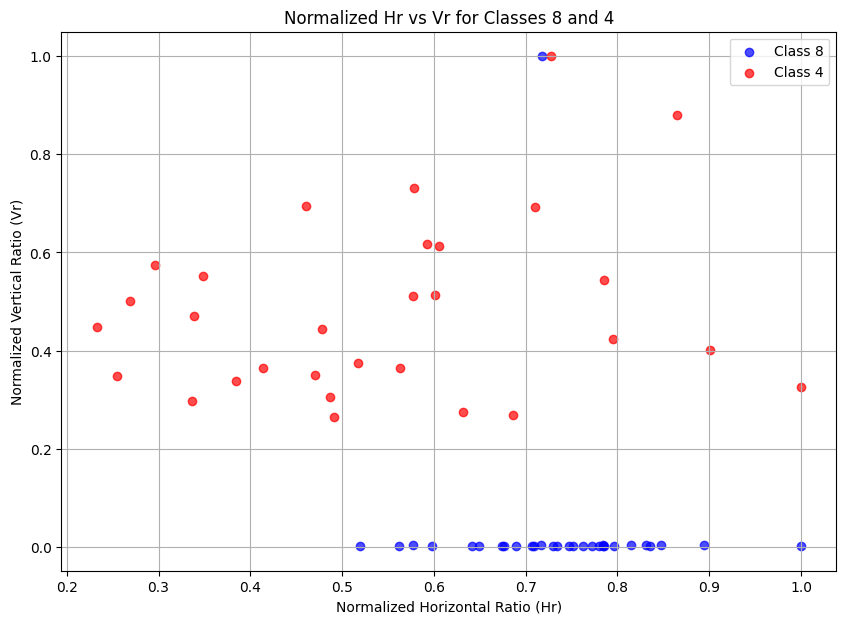

In [102]:
import matplotlib.pyplot as plt

# Extract Hr and Vr for class 8 (assuming lista_8 contains [Hr, Vr] for class 8)
hr_8 = [item[0] for item in lista_8]
vr_8 = [item[1] for item in lista_8]

# Extract Hr and Vr for class 4 (assuming lista_4 contains [Hr, Vr] for class 4)
hr_4 = [item[0] for item in lista_4]
vr_4 = [item[1] for item in lista_4]

plt.figure(figsize=(10, 7))

# Plotting class 8
plt.scatter(hr_8, vr_8, color='blue', label='Class 8', alpha=0.7)

# Plotting class 4
plt.scatter(hr_4, vr_4, color='red', label='Class 4', alpha=0.7)

plt.title('Normalized Hr vs Vr for Classes 8 and 4')
plt.xlabel('Normalized Horizontal Ratio (Hr)')
plt.ylabel('Normalized Vertical Ratio (Vr)')
plt.legend()
plt.grid(True)
plt.show()